In [27]:
import numpy as np
import torch

def generate(N):
    rate = np.random.uniform(1,10)
    y = np.random.poisson(rate, size=(N,))
    x = np.full_like(y, rate)
    return torch.FloatTensor(x.reshape(-1,1)),torch.LongTensor(y)


width = 128
model = torch.nn.Sequential(
    torch.nn.Linear(1,width),
    torch.nn.ReLU(),
    torch.nn.Linear(width,width),
    torch.nn.ReLU(),
    torch.nn.Linear(width,width),
    torch.nn.ReLU(),
    torch.nn.Linear(width,50),
)


opt = torch.optim.Adam(model.parameters(), lr=1e-3)

for step in range(10000):
    x,y = generate(10000)
    pred = model(x)
    loss = torch.nn.functional.cross_entropy(pred, y)
    loss.backward()
    if step % 1000 == 0:
        print(step,loss.item())
    opt.step()
    opt.zero_grad()

0 4.109316349029541
1000 1.991995096206665
2000 2.5587267875671387
3000 2.0374643802642822
4000 2.4153223037719727
5000 2.1277031898498535
6000 2.43803334236145
7000 2.4041125774383545
8000 1.4733467102050781
9000 1.7657968997955322


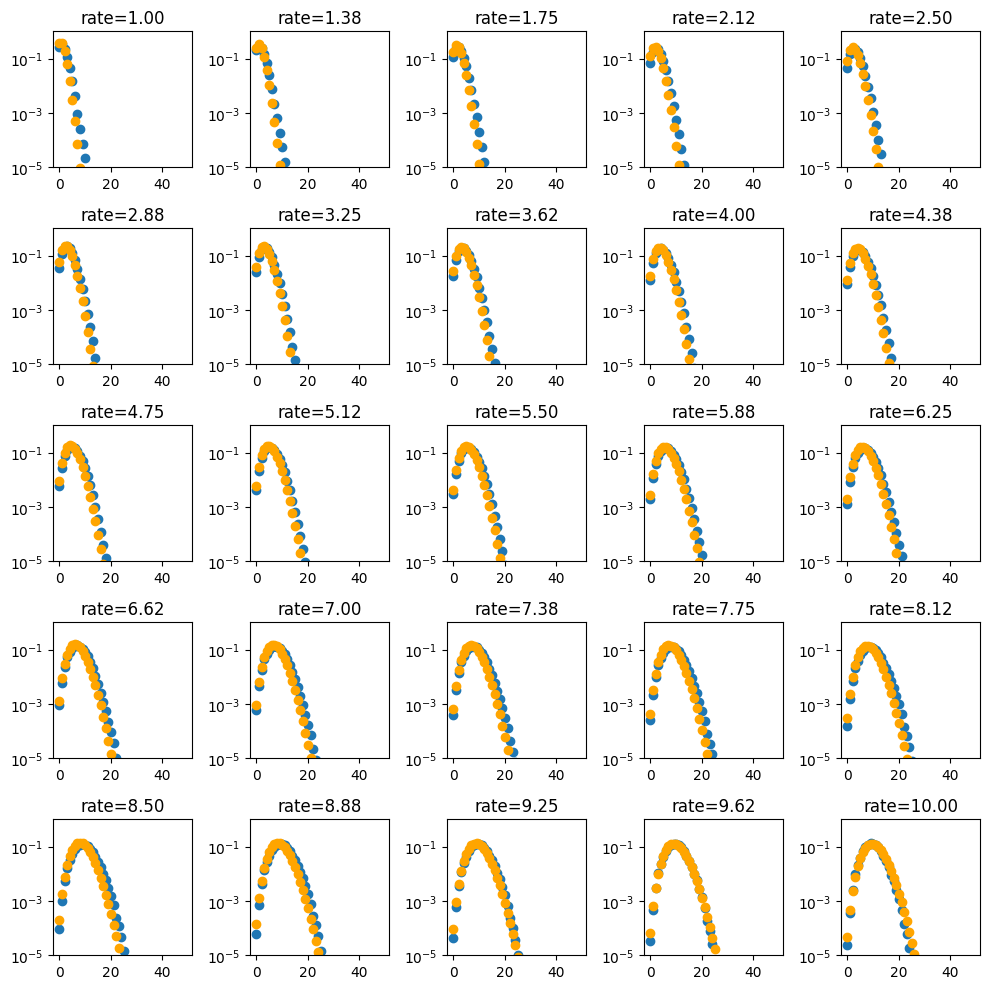

In [36]:
import matplotlib.pyplot as plt
import scipy.stats as stats

x,y = generate(1)
with torch.no_grad():
    pred = model(x)


f,axarr = plt.subplots(5,5)
f.set_size_inches(10,10)

rates = np.linspace(1,10,axarr.size)

for ax,rate in zip(axarr.flatten(), rates):
    x = torch.FloatTensor([[rate]])
    with torch.no_grad():
        pred = model(x)
    n = np.arange(50)
    ax.scatter(n,torch.nn.functional.softmax(pred, dim=-1)[0])
    ax.scatter(n,stats.poisson.pmf(n, rate), color = 'orange')
    ax.set_yscale('log')
    ax.set_ylim(1e-5,1)
    #ratio 
    # ax.scatter(n,np.log(torch.nn.functional.softmax(pred, dim=-1)[0]/stats.poisson.pmf(n, rate)))
    # ax.set_ylim(-2,2)
    ax.set_title(f"rate={rate:.2f}")

plt.tight_layout()
plt.savefig("poisson_approximation.png")

In [37]:
!open .